In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import math
import os
from pathlib import Path
from datetime import datetime

In [2]:
os.getcwd()

'/home/camarada/Documents/projects/temp-grss-nasa/daily_max_temp/forecast'

In [3]:
!python forecast_deterministic.py --lat 51.505 --lon 0.055 --time 'Europe/London' --city London --root-dir ./apiresult/deterministic


Fetching forecasts for London (51.5050, 0.0550)
Target dates: ['2026-03-20', '2026-03-21', '2026-03-22']

  Fetching ECMWF IFS HRES 9km...
  Fetching UKMO UK 2km...
  Fetching UKMO Global 10km...
  Fetching MeteoFrance ARPEGE Europe...
  [WARN] MeteoFrance ARPEGE Europe: request failed — HTTPSConnectionPool(host='api.open-meteo.com', port=443): Read timed out. (read timeout=30)
  Fetching DWD Germany...
  Fetching DWD ICON EU...

=== Daily Maximum Temperature (°C) per model ===
          date               model                time  temperature
0   2026-03-20  ECMWF IFS HRES 9km 2026-03-20 15:00:00         13.6
1   2026-03-20         UKMO UK 2km 2026-03-20 15:00:00         15.1
2   2026-03-20    UKMO Global 10km 2026-03-20 16:00:00         14.5
3   2026-03-20         DWD Germany 2026-03-20 16:00:00         12.9
4   2026-03-20         DWD ICON EU 2026-03-20 16:00:00         12.2
5   2026-03-21  ECMWF IFS HRES 9km 2026-03-21 14:00:00         12.0
6   2026-03-21         UKMO UK 2km 2026-

In [4]:
! python forecast_ensemble.py --lat 51.505 --lon 0.055 --timezone 'Europe/London' --city London --root-dir ./apiresult/ensemble


  Fetching Ensemble CDF Data
  Loc: 51.505, 0.055 | Days: 3

  Requesting models: 7 ensembles...
── Daily Max Temperature Summary (°C) ───────────────────────
      Date  Mean StdDev P10 (Cold) P90 (Hot)  Members
2026-03-20 13.50   1.05      12.16     14.70      217
2026-03-21 12.19   2.15      10.04     13.90      217

[INFO] Raw hourly data saved to: apiresult/ensemble/ensemble-London_2026-03-19-10:03.parquet


In [4]:

def get_most_recent_file(folder):
    files = os.listdir(folder)
    def extract_datetime(filename):
        timestamp_str = Path(filename).stem.split('_',2)[1]
        return datetime.strptime(timestamp_str, "%Y-%m-%d-%H:%M")
    
    return max(files, key=extract_datetime)


In [5]:
folder_deterministic = "/home/camarada/Documents/projects/temp-grss-nasa/daily_max_temp/forecast/apiresult/deterministic"
folder_ensemble = "/home/camarada/Documents/projects/temp-grss-nasa/daily_max_temp/forecast/apiresult/ensemble"

mr_det_file = get_most_recent_file(folder_deterministic)
mr_ensem_file = get_most_recent_file(folder_ensemble)
print(f" most recent file:\n deterministic:{mr_det_file}")
print(f" ensemble :{mr_ensem_file}")
## create the df 
df_det = pd.read_parquet(
    os.path.join(folder_deterministic, mr_det_file)
)

df_ens = pd.read_parquet(
    os.path.join(folder_ensemble, mr_ensem_file)
)
df_det['date'] =pd.to_datetime(df_det['date'], yearfirst=True)
df_ens = df_ens.reset_index().rename(columns={'index':'date'})
df_ens['date'] = pd.to_datetime(df_ens['date'],
                                yearfirst=True)
 

 most recent file:
 deterministic:London-Deterministic_2026-03-19-10:03.parquet
 ensemble :ensemble-London_2026-03-19-10:03.parquet


In [6]:
df_det

,date,model,time,temperature
0,2026-03-20,ECMWF IFS HRES 9km,2026-03-20 15:00:00,13.6
1,2026-03-20,UKMO UK 2km,2026-03-20 15:00:00,15.1
2,2026-03-20,UKMO Global 10km,2026-03-20 16:00:00,14.5
3,2026-03-20,DWD Germany,2026-03-20 16:00:00,12.9
4,2026-03-20,DWD ICON EU,2026-03-20 16:00:00,12.2
5,2026-03-21,ECMWF IFS HRES 9km,2026-03-21 14:00:00,12.0
6,2026-03-21,UKMO UK 2km,2026-03-21 00:00:00,8.2
7,2026-03-21,UKMO Global 10km,2026-03-21 15:00:00,13.3
8,2026-03-21,DWD Germany,NaT,NaN
9,2026-03-21,DWD ICON EU,2026-03-21 14:00:00,12.8


In [11]:
def calc_mean_std_deterministic_forecast(temperature:np.ndarray,
                                        weights:np.ndarray):
    """
    compute mean and weighted std
    """
    # weighted mean
    mu_w = np.average(temperature,
                        weights=weights)
    
    # weight variance and std
    variance_w = np.average((temperature - mu_w)**2,
                            weights=weights
                            )
    
    # std
    std_w = np.sqrt(variance_w)

    return mu_w, std_w

In [12]:
weights_dict = {'DWD Germany':0.1,
                'DWD ICON EU':0.1,
                'ECMWF IFS HRES 9km':0.2,
                'MeteoFrance ARPEGE Europe': 0.2,
                'UKMO Global 10km':	0.1,
                'UKMO UK 2km':0.3
                }

analysis_date = "2026-03-20"


## filter the df 
df_day = (df_det.loc[df_det['date'] == analysis_date]).sort_values(
                                                                    by='model'
                                                                    ) ## import to sort! 

## get the weights
weights = [weights_dict[i] for i in df_day['model'].values]

## calc mean and std
mu_w, std_w = calc_mean_std_deterministic_forecast(
    temperature = df_day['temperature'].values,
    weights = weights 
)



### Report

#### Dterministic

In [ ]:
df_print = df_day.head(len(df_day['model'].unique()))[['model','time','temperature']]


def print_deterministic_report(df_print, 
                            analysis_date,
                            mu_w,
                            std_w,
                            weights_dict,
                            verbose_weight=True):
    #print_deterministic
    print("Deterministic models: ")
    print(f"Dia:{analysis_date}")
    print("-"*30)


    # Determine a reasonable width for the model column
    model_width = max(df_print['model'].str.len()) + 2  # +2 for spacing

    ## head of the print
    print(f"{'model':<{model_width}} | {'Temperature':>5} | {'Time':>5} | {'rel weight':<10}")
    for _, row in df_print.iterrows():
        if verbose_weight:
            assert weights_dict is not None
            print(f"{row['model']:<{model_width}} | {row['temperature']:>5} °C | at {row['time'].strftime('%H:%M')} | {weights_dict[row['model']]}")
        else:
            print(f"{row['model']:<{model_width}} | {row['temperature']:>5} °C | at {row['time'].strftime('%H:%M')}")

    print("-"*30)
    print("Weighted:")
    print(f"Average:{float(mu_w):.2f}")
    print(f"Standard Desviation:{std_w:.2f}")
    print("-"*30)

print_deterministic_report(df_print,
                            analysis_date,
                            mu_w,
                            std_w,
                            weights_dict)
# TODO:
# ENSEMBLE
# HISTORICAL ERROR REGARDING UK2KM

Deterministic models: 
Dia:2026-03-20
------------------------------
model                | Temperature |  Time | rel weight
DWD Germany          |  12.9 °C | at 16:00 | 0.1
DWD ICON EU          |  12.2 °C | at 16:00 | 0.1
ECMWF IFS HRES 9km   |  13.6 °C | at 15:00 | 0.2
UKMO Global 10km     |  14.5 °C | at 16:00 | 0.1
UKMO UK 2km          |  15.1 °C | at 15:00 | 0.3
------------------------------
Weighted:
Average:14.01
Standard Desviation:1.04
------------------------------


In [18]:
weights_dict

{'DWD Germany': 0.1,
 'DWD ICON EU': 0.1,
 'ECMWF IFS HRES 9km': 0.2,
 'MeteoFrance ARPEGE Europe': 0.2,
 'UKMO Global 10km': 0.1,
 'UKMO UK 2km': 0.3}

In [ ]:
df_day.head(len(df_day['model'].unique()))[['model','time','temperature']]

def report_deterministic(df_det:pd.DataFrame,
                        analysis_day,
                        weight_dicts:dict):
    # TODO 
    ## check if date is pd_datetime instead of convert pd_datetime

    ## sort 
    df_det = df_det.sort_values(by=['date','model'])

    #filter for the given day
    ## filter the df 
    df_day = (df_det.loc[df_det['date'] == analysis_date]).sort_values(
                                                                    by='model'
                                                                    ) ## import to sort! 
    ## get the weights
    weights = [weights_dict[i] for i in df_day['model'].values]

    ## calc mean and std
    mu_w, std_w = calc_mean_std_deterministic_forecast(
        temperature = df_day['temperature'].values,
        weights = weights 
    )

    print_deterministic_report(df_print,
                            analysis_date,
                            mu_w,
                            std_w,
                            weights_dict,
                            verbose_weight=True)

    ## TODO
    #how to send as a message in telegram

SyntaxError: incomplete input (151365244.py, line 25)

#### ENSEMBLE

In [ ]:
df_print.rename(columns={})

TypeError: Cannot specify both 'axis' and any of 'index' or 'columns'

In [55]:
for i, row in df_print.iterrows():
    print(row['2026-03-20'])

217.0
13.500921658986174
1.0520698638702195
10.3
13.0
13.6
14.2
16.0


In [ ]:
# 1. Isolate the row for the specific date
analysis_day = "2026-03-20"
ensemble_members = (df_ens.loc[df_ens['date']==analysis_day]).set_index('date') #df



bin_min = math.floor(ensemble_members.values.reshape(-1).min())
bin_max = math.ceil(ensemble_members.values.reshape(-1).max())
hist, bin_edges = np.histogram(ensemble_members.values.reshape(-1),
                                bins = abs(bin_min - bin_max),
                                range=(
                                    bin_min,bin_max
                                )
                                )

print("Ensemble models:")
print(f"Total number of ensembles:{len(df_ens.columns)-1}")
df_print = (df_ens.loc[df_ens['date']==analysis_day]).set_index('date').T.describe()

for i, row in df_print.iterrows():
        print(f"{i} | {row[analysis_day]:.2f}")


Ensemble models:
Total number of ensembles:217


KeyError: 'date'

In [34]:
(df_ens.loc[df_ens['date']==analysis_day]).set_index('date').T.describe()

date,2026-03-20
count,217.000000
mean,13.500922
std,1.052070
min,10.300000
25%,13.000000
50%,13.600000
75%,14.200000
max,16.000000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def calculate_ensemble_distribution(member_values: np.ndarray):
    """
    Fits a KDE to the ensemble members.
    Returns the KDE object which acts as the PDF/CDF generator.

    Args:
        member_values: np.ndarray.
    """
    # Remove NaNs if any
    data = member_values[~np.isnan(member_values)]
    
    # Fit Kernel Density Estimator
    kde = gaussian_kde(data)
    
    # To get CDF from KDE, we integrate the PDF. 
    # Scipy KDE doesn't have a direct .cdf(), so we use .integrate_box_1d
    return kde

def get_kde_prob_in_bin(kde, low, high):
    """
    Returns the probability P(low < T < high) using the KDE.
    """
    return kde.integrate_box_1d(low, high)

def plot_ensemble_vs_market(kde, member_values, strikes):
    """
    Plots the actual ensemble histogram, the KDE, and the CDF.
    """
    x = np.linspace(min(member_values)-2, max(member_values)+2, 500)
    pdf_values = kde.evaluate(x)
    
    # Calculate CDF by integrating from -infinity to each x
    cdf_values = [kde.integrate_box_1d(-np.inf, val) for val in x]

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot Histogram of raw ensemble members
    ax1.hist(member_values, bins=30, density=True, alpha=0.3, color='gray', label='Raw Members')
    # Plot KDE PDF
    ax1.plot(x, pdf_values, color='tab:blue', lw=3, label='KDE (Model Likelihood)')
    ax1.set_ylabel('Density', color='tab:blue')

    # Plot CDF
    ax2 = ax1.twinx()
    ax2.plot(x, cdf_values, color='tab:red', lw=2, ls='--', label='CDF')
    ax2.set_ylabel('Cumulative Probability', color='tab:red')

    if strikes:
        for s in strikes:
            ax1.axvline(x=s, color='black', alpha=0.3, ls=':')
            # Label the CDF value at each strike
            p_below = kde.integrate_box_1d(-np.inf, s)
            ax2.scatter(s, p_below, color='tab:red')
            ax2.annotate(f'{p_below:.1%}', (s, p_below), xytext=(5,5), textcoords='offset points', color='red')

    plt.title("Ensemble KDE Distribution (N=217)")
    plt.show()

In [ ]:
np.histogram(df_day[''])

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_forecast_distribution(mu: float, std: float, strikes: list = None):
    """
    Plots PDF and CDF together to visualize the betting landscape.
    """
    # Create range for X axis (4 standard deviations)
    x = np.linspace(mu - 4*std, mu + 4*std, 500)
    pdf = norm.pdf(x, mu, std)
    cdf = norm.cdf(x, mu, std)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # PDF Plot (Likelihood)
    ax1.plot(x, pdf, color='tab:blue', lw=2, label='PDF (Likelihood)')
    ax1.fill_between(x, pdf, color='tab:blue', alpha=0.2)
    ax1.set_xlabel('Temperature (°C)')
    ax1.set_ylabel('Density', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # CDF Plot (Cumulative Prob)
    ax2 = ax1.twinx()
    ax2.plot(x, cdf, color='tab:red', lw=2, ls='--', label='CDF (Cumulative)')
    ax2.set_ylabel('Cumulative Probability', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # Add vertical lines for market strikes if provided
    if strikes:
        for s in strikes:
            ax1.axvline(x=s, color='gray', alpha=0.5, linestyle=':')
            prob = norm.cdf(s, mu, std)
            ax2.scatter(s, prob, color='tab:red')
            ax2.annotate(f'{prob:.1%}', (s, prob), textcoords="offset points", xytext=(0,10), ha='center', color='tab:red')

    plt.title(f'Weather Market Fusion Model\n mean={mu:.2f}, std={std:.2f}')
    fig.tight_layout()
    plt.show()

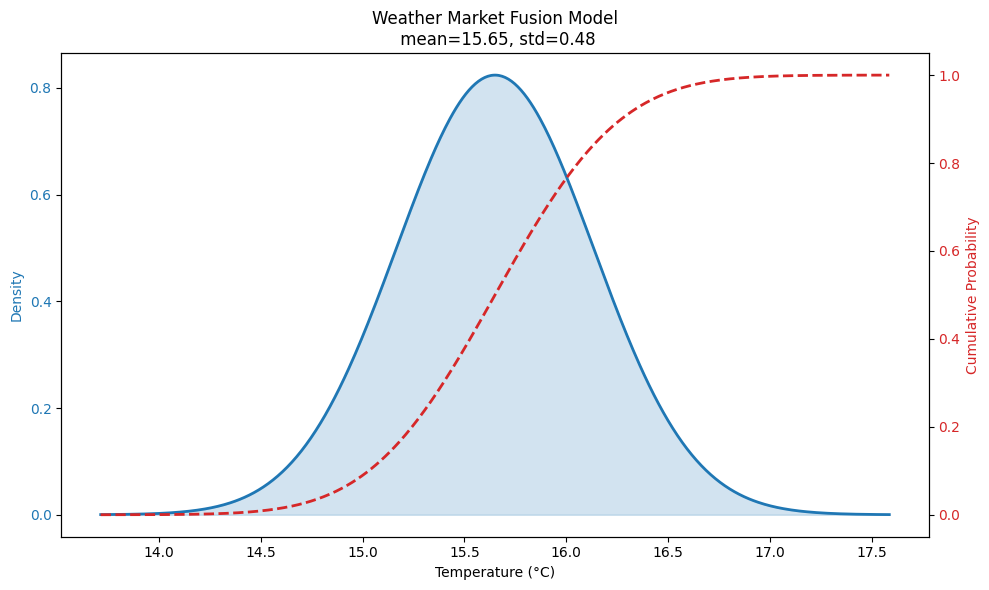

In [35]:
plot_forecast_distribution(mu_w, std_w)

In [36]:
def calculate_market_edge(mu: float,
                         std: float,
                            bin_low: float,
                            bin_high: float,
                            market_price: float):
    """
    Calculates the probability of a specific temperature bin and the edge vs market.
    """
    # Model probability for the bin [low, high]
    model_prob = norm.cdf(bin_high, mu, std) - norm.cdf(bin_low, mu, std)
    edge = model_prob - market_price
    
    return model_prob, edge

def calculate_kelly_size(model_prob: float,
                            market_price: float,
                            kelly_fraction: float = 0.25):
    """
    Computes the Kelly Criterion fraction.
    kelly_fraction: Use 'Fractional Kelly' (e.g., 0.25) to avoid over-betting.
    """
    if model_prob <= market_price:
        return 0.0  # No edge, no bet
    
    # b = decimal odds - 1. For Polymarket, odds are 1/price
    b = (1 / market_price) - 1
    p = model_prob
    q = 1 - p
    
    f_star = (b * p - q) / b
    
    # Apply fractional Kelly (e.g., Quarter-Kelly) for safety
    return max(0, f_star * kelly_fraction)

In [76]:
calculate_kelly_size(0.38, 0.2, 0.25)

0.05625

In [39]:
# 2. Add your "Safety Inflation" to std_w (highly recommended)
std_final = np.sqrt(std_w**2 + 0.5**2) 

# 3. Define the Polymarket you are looking at
# Example: "Will Tmax be between 14C and 15C?" priced at $0.45
strike_low, strike_high = 17.0, 17.9
current_price = 0.44

# 4. Calculate
prob, edge = calculate_market_edge(mu_w,
                                    std_final, 
                                    strike_low, strike_high, 
                                    current_price)
bet_size = calculate_kelly_size(prob, current_price, kelly_fraction=0.1) # 1/10th Kelly is safer

print(f"Model Prob: {prob:.2%}")
print(f"Edge: {edge:+.2%}")
print(f"Suggested Bet: {bet_size:.2%} of bankroll")

Model Prob: 2.56%
Edge: -41.44%
Suggested Bet: 0.00% of bankroll


### Ensemble of models

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def calculate_ensemble_distribution(member_values: np.ndarray):
    """
    Fits a KDE to the ensemble members.
    Returns the KDE object which acts as the PDF/CDF generator.

    Args:
        member_values: np.ndarray.
    """
    # Remove NaNs if any
    data = member_values[~np.isnan(member_values)]
    
    # Fit Kernel Density Estimator
    kde = gaussian_kde(data)
    
    # To get CDF from KDE, we integrate the PDF. 
    # Scipy KDE doesn't have a direct .cdf(), so we use .integrate_box_1d
    return kde

def get_kde_prob_in_bin(kde, low, high):
    """
    Returns the probability P(low < T < high) using the KDE.
    """
    return kde.integrate_box_1d(low, high)

def plot_ensemble_vs_market(kde, member_values, strikes):
    """
    Plots the actual ensemble histogram, the KDE, and the CDF.
    """
    x = np.linspace(min(member_values)-2, max(member_values)+2, 500)
    pdf_values = kde.evaluate(x)
    
    # Calculate CDF by integrating from -infinity to each x
    cdf_values = [kde.integrate_box_1d(-np.inf, val) for val in x]

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot Histogram of raw ensemble members
    ax1.hist(member_values, bins=30, density=True, alpha=0.3, color='gray', label='Raw Members')
    # Plot KDE PDF
    ax1.plot(x, pdf_values, color='tab:blue', lw=3, label='KDE (Model Likelihood)')
    ax1.set_ylabel('Density', color='tab:blue')

    # Plot CDF
    ax2 = ax1.twinx()
    ax2.plot(x, cdf_values, color='tab:red', lw=2, ls='--', label='CDF')
    ax2.set_ylabel('Cumulative Probability', color='tab:red')

    if strikes:
        for s in strikes:
            ax1.axvline(x=s, color='black', alpha=0.3, ls=':')
            # Label the CDF value at each strike
            p_below = kde.integrate_box_1d(-np.inf, s)
            ax2.scatter(s, p_below, color='tab:red')
            ax2.annotate(f'{p_below:.1%}', (s, p_below), xytext=(5,5), textcoords='offset points', color='red')

    plt.title("Ensemble KDE Distribution (N=217)")
    plt.show()

In [ ]:
# 1. Isolate the row for the specific date
target_date = "2026-03-19"
row = df_ens.loc[df_ens['date']==target_date]

row

np.histogram(ensemble_members.reshape(-1),
            bins = abs(math.floor(ensemble_members.reshape(-1).min()) - math.ceil(ensemble_members.reshape(-1).max())),
            range=(
                math.floor(ensemble_members.reshape(-1).min()),math.ceil(ensemble_members.reshape(-1).max())
            ))

,date,temperature_2m_ecmwf_ifs025_ensemble,temperature_2m_member01_ecmwf_ifs025_ensemble,temperature_2m_member02_ecmwf_ifs025_ensemble,temperature_2m_member03_ecmwf_ifs025_ensemble,temperature_2m_member04_ecmwf_ifs025_ensemble,temperature_2m_member05_ecmwf_ifs025_ensemble,temperature_2m_member06_ecmwf_ifs025_ensemble,temperature_2m_member07_ecmwf_ifs025_ensemble,temperature_2m_member08_ecmwf_ifs025_ensemble,...,temperature_2m_member10_icon_d2_eps,temperature_2m_member11_icon_d2_eps,temperature_2m_member12_icon_d2_eps,temperature_2m_member13_icon_d2_eps,temperature_2m_member14_icon_d2_eps,temperature_2m_member15_icon_d2_eps,temperature_2m_member16_icon_d2_eps,temperature_2m_member17_icon_d2_eps,temperature_2m_member18_icon_d2_eps,temperature_2m_member19_icon_d2_eps
0,2026-03-19,15.2,15.2,15.3,15.4,14.9,15.0,15.0,15.2,14.8,...,16.2,16.2,16.3,16.0,16.0,16.2,16.2,16.7,16.0,16.1


In [61]:
np.histogram(ensemble_members.reshape(-1),
            bins = abs(math.floor(ensemble_members.reshape(-1).min()) - math.ceil(ensemble_members.reshape(-1).max())),
            range=(
                math.floor(ensemble_members.reshape(-1).min()),math.ceil(ensemble_members.reshape(-1).max())
            ))

(array([ 12,  84, 110,  11]), array([14., 15., 16., 17., 18.]))

In [54]:
import math

In [58]:
abs(math.floor(ensemble_members.reshape(-1).min()) - math.ceil(ensemble_members.reshape(-1).max()))

4

BINGO! Market 15-16C | Prob: 41.4% | Edge: +35.4% | Bet: 7.5%
BINGO! Market 16-17C | Prob: 44.3% | Edge: +9.3% | Bet: 2.9%


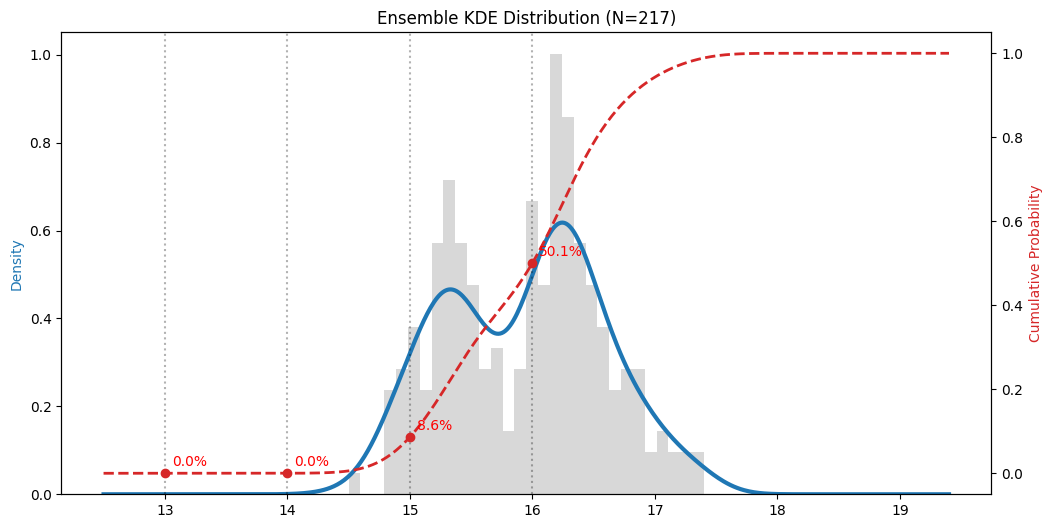

In [48]:
# filter for date 
target_date = "2026-03-19"
row = df_ens.loc[df_ens['date']==target_date]

# convert all member columns to a numpy array
ensemble_members = row.set_index('date').values.astype(float)

# 3. Generate the distribution
kde_model = calculate_ensemble_distribution(ensemble_members.reshape(-1))

# 4. Market Analysis Loop
markets = [
    {'bin': (15, 16), 'price': 0.06},
    {'bin': (16, 17), 'price': 0.35},
    {'bin': (17, 18), 'price': 0.44},
    {'bin': (18, 19), 'price': 0.12}
]

for m in markets:
    low, high = m['bin']
    price = m['price']
    
    # Calculate Edge
    prob = get_kde_prob_in_bin(kde_model, low, high)
    edge = prob - price
    
    # Calculate Kelly
    kelly = calculate_kelly_size(prob, price, kelly_fraction=0.2)
    
    if edge > 0.05:
        print(f"BINGO! Market {low}-{high}C | Prob: {prob:.1%} | Edge: {edge:+.1%} | Bet: {kelly:.1%}")

# 5. Visualize
plot_ensemble_vs_market(kde_model, ensemble_members.reshape(-1), strikes=[13, 14, 15, 16])

### Combining both models

In [97]:
def analyze_fusion_edge(mu_det:float, 
                        std_det:float, 
                        kde_ens, 
                        bin_low, 
                        bin_high, 
                        market_price):

    """
    Blends deterministic certainty with ensemble variance.

    Aegs:
        mu_det: Weighted Average of Deterministic Models
        std_det: Weighted std of deterministic models
        kde_ens = gaussian kernel class of the ensemble of models
        bin_low: the lower bin of the market
        bin_high: the upper bounder bin
        market_price: current market price at the moment 
    """
    # Deterministic
    prob_det = norm.cdf(bin_high, mu_det, std_det) - norm.cdf(bin_low, mu_det, std_det)
    
    # Ensemble Prob
    prob_ens = kde_ens.integrate_box_1d(bin_low, bin_high)
    
    # Weighted Blend (e.g., 70% Deterministic / 30% Ensemble)
    final_prob = (0.7 * prob_det) + (0.3 * prob_ens)
    
    edge = final_prob - market_price
    kelly = calculate_kelly_size(final_prob, market_price, kelly_fraction=0.15)
    
    return {
        'Final Prob': final_prob,
        'Det Contribution': prob_det,
        'Ens Contribution': prob_ens,
        'Edge': edge,
        'Kelly Bet': kelly
    }

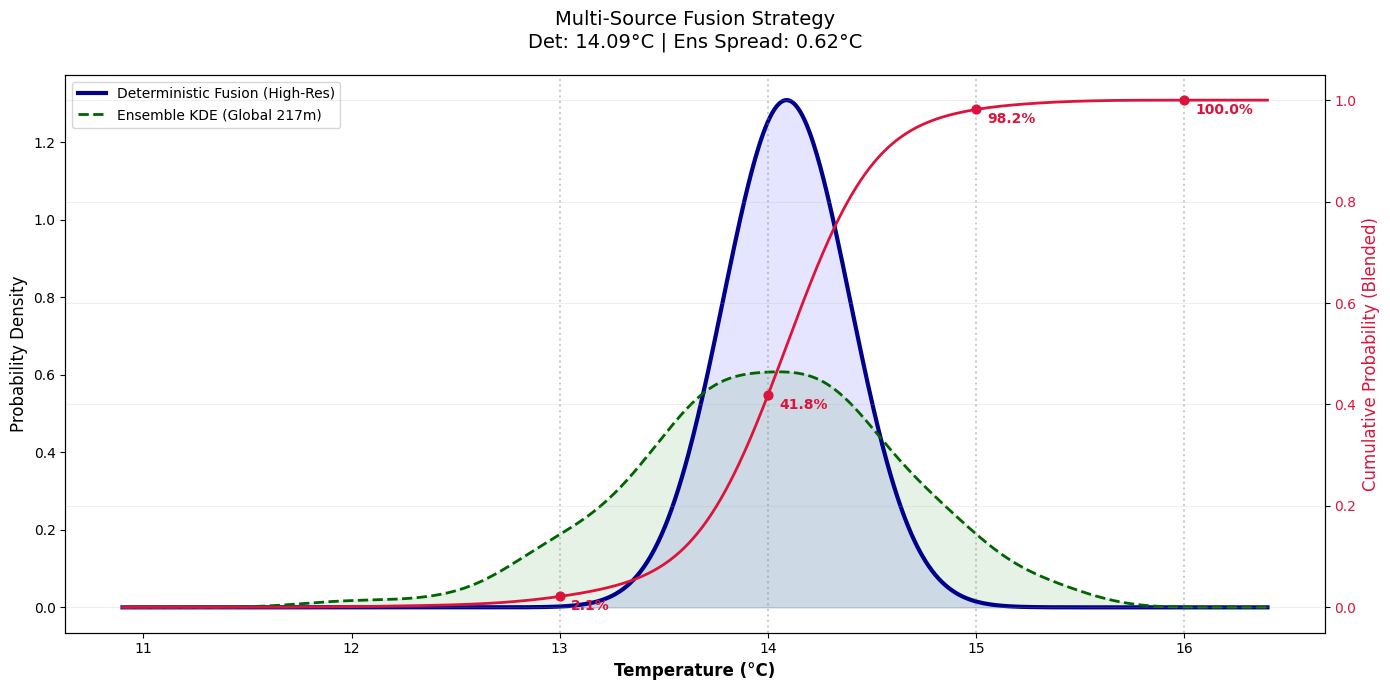

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

def plot_fusion_vs_ensemble(mu_det, std_det, kde_ens, ensemble_members, strikes=None):
    """
    Overlays the Deterministic Normal curve on top of the Ensemble KDE.
    """
    # 1. Setup X-axis range based on the full spread of data
    x_min = min(ensemble_members.min(), mu_det - 4*std_det)
    x_max = max(ensemble_members.max(), mu_det + 4*std_det)
    x = np.linspace(x_min - 1, x_max + 1, 1000)

    # 2. Calculate PDF values
    pdf_det = norm.pdf(x, mu_det, std_det)
    pdf_ens = kde_ens.evaluate(x)
    
    # 3. Calculate CDF for the blended model (70/30 Blend)
    cdf_det = norm.cdf(x, mu_det, std_det)
    cdf_ens = np.array([kde_ens.integrate_box_1d(-np.inf, val) for val in x])
    cdf_blend = (0.7 * cdf_det) + (0.3 * cdf_ens)

    # 4. Create Plot
    fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)

    # Plot Deterministic PDF (High Res)
    ax1.plot(x, pdf_det, color='darkblue', lw=3, label='Deterministic Fusion (High-Res)')
    ax1.fill_between(x, pdf_det, color='blue', alpha=0.1)

    # Plot Ensemble KDE PDF (Global Spread)
    ax1.plot(x, pdf_ens, color='darkgreen', lw=2, ls='--', label='Ensemble KDE (Global 217m)')
    ax1.fill_between(x, pdf_ens, color='green', alpha=0.1)

    ax1.set_xlabel('Temperature (°C)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Probability Density', fontsize=12)
    ax1.legend(loc='upper left')

    # 5. Add CDF to Secondary Axis
    ax2 = ax1.twinx()
    ax2.plot(x, cdf_blend, color='crimson', lw=2, label='Blended CDF (70/30)')
    ax2.set_ylabel('Cumulative Probability (Blended)', color='crimson', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='crimson')

    # 6. Add Market Strikes (1°C Bins)
    if strikes:
        for s in strikes:
            ax1.axvline(x=s, color='gray', alpha=0.4, ls=':')
            # Calculate Blended Prob at strike
            p_det = norm.cdf(s, mu_det, std_det)
            p_ens = kde_ens.integrate_box_1d(-np.inf, s)
            p_blend = (0.7 * p_det) + (0.3 * p_ens)
            
            ax2.scatter(s, p_blend, color='crimson', s=40, zorder=5)
            ax2.annotate(f'{p_blend:.1%}', (s, p_blend), xytext=(8, -10), 
                         textcoords='offset points', color='crimson', fontweight='bold')

    plt.title(f'Multi-Source Fusion Strategy\nDet: {mu_det:.2f}°C | Ens Spread: {ensemble_members.std():.2f}°C', 
              fontsize=14, pad=20)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# --- EXAMPLE EXECUTION ---
plot_fusion_vs_ensemble(mu_w, std_w, kde_model, ensemble_members, strikes=[13, 14, 15, 16])